In [1]:
%load_ext autoreload
%autoreload 2
    
import os
import pickle
import dill

from itertools import accumulate
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

from pydmd import DMD, BOPDMD, FbDMD, MrDMD
from pydmd.plotter import plot_eigs, plot_summary, plot_modes_2D
from pydmd.preprocessing import hankel_preprocessing

from IPython.display import display
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

from scipy.ndimage import gaussian_filter

from tqdm.autonotebook import tqdm, trange

from scipy.signal import fftconvolve


/var/folders/s8/_x7yhly96g707tvgp1hkr_bh0000gn/T/ipykernel_10953/1916304584.py:24: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:

import sys
sys.path.append('/Users/giorgioaurina/Desktop/Paolo/Progressive-Multifidelity-Learning/src/modules/')

from plot_jupyter import contour_compare, contour_data

In [3]:

from data_wrangle import get_days_before, get_test_set, window_mean, thin_data, del_leap
from dmd_routines import reshape_data2dmd, train_dmd, reshape_Psi2data, eval_dmd, eval_dmd_latent, bootstrap_train_dmd, eval_dmd_ensemble, eval_dmd_latent

import xarray as xr
from dataclasses import dataclass

In [4]:
# Specify the data
year = 34
day = 0 # CRITICAL: Use day=0 for proper alignment. Day=1 causes phase shift.
window = 1

thin = 2
rank = 5
N_boot_strap = 50
eig_constraints={
                        "stable", # choose Re(lambda)<0
                        "conjugate_pairs", # force complex conjugate pairs
                        }

threshold = 0.3

# Specify prediction

T_pred = 730

In [5]:
with open('/Users/giorgioaurina/Desktop/Paolo/Progressive-Multifidelity-Learning/data/ice/Antarctic_years_1989_2024i.pkl', 'rb') as f:
    mask_land_, mask_ice_, data_, data_mean_month_, data_mean_week_, x_, y_ = dill.load(f)

- `data_` is a list of 36 years where each one has dimension (n_day, nx, ny), where n_day = 365, nx=ny=432
- `mask_land_` is a boolean mask to indicate where there is land or water
- `data_mean_month_` and `data_mean_week_` have monthly and weekly time frequency (instead of daily)

In [6]:
data, data_mean_month, data_mean_week, x, y, mask_ice, mask_land = \
    thin_data(thin, data_, data_mean_month_, data_mean_week_, x_, y_, mask_ice_, mask_land_)

data = del_leap(data)
del data_, data_mean_month_, data_mean_week_
ny, nx = data[0].shape[1:]

mask_ice_.shape, mask_ice.shape

(365, 216, 216)
(12, 216, 216)
(52, 216, 216)


  0%|          | 0/36 [00:00<?, ?it/s]

((432, 432), (216, 216))

In [ ]:
for i in range (36):
    print(np.max(data[i]), np.min(data[i]))

# Compute DMD

In [ ]:
# Use np.arange to get integer indices
T_train = 365 * 2
years = np.arange(2, 36)  # Creates array([2, 3, 4, ..., 35]) - INTEGERS
window = 1

# Pre-allocate arrays instead of using lists (more memory efficient)
print("Collecting training data for all years...")
print(f"This will create arrays of shape: ({len(years)}, {T_train + window - 1}, {ny}, {nx})")

# Get first sample to determine exact shape
X0_sample = get_days_before(data, years[0], day, T_train + window - 1)
actual_time_steps = X0_sample.shape[0]

# Pre-allocate arrays with correct shape
previous_days = np.zeros((len(years), actual_time_steps, ny, nx), dtype=np.float32)
previous_wmeans = np.zeros((len(years), actual_time_steps, ny, nx), dtype=np.float32)

print(f"Allocated memory for shape: {previous_days.shape}")
print(f"Memory usage: ~{previous_days.nbytes / 1024**3:.2f} GB per array")

# Fill arrays year by year
for idx, year in enumerate(tqdm(years, desc="Loading years")):
    X0_ = get_days_before(data, year, day, T_train + window - 1)
    previous_days[idx] = X0_
    X0_wm = window_mean(X0_, window)
    previous_wmeans[idx] = X0_wm

print(f"\n✓ Data collection complete!")
print(f"previous_days shape: {previous_days.shape}")
print(f"previous_wmeans shape: {previous_wmeans.shape}")

In [ ]:
t_train = np.arange(-T_train, 0)
# time delay and dmd snapshots
X_delayed = []
for year in years:
    X0_ = previous_wmeans[year - 2]  # Adjust index since years start from 2
    X_d, t_delayed, data_shape = reshape_data2dmd(X0_, t_train, time_delay=2, 
                                            mask=mask_ice,
                                            isKeepFirstTimes=True)
    X_delayed.append(X_d)

X_delayed = np.array(X_delayed)
print(f"X_delayed shape: {X_delayed.shape}")
print(f"t_delayed shape: {t_delayed.shape}")    
print(f"data_shapes shape: {data_shape}")

In [ ]:
# Check for data quality issues before DMD training
print("Checking data quality in X_delayed...")
for idx, X_d in enumerate(X_delayed):
    has_nan = np.isnan(X_d).any()
    has_inf = np.isinf(X_d).any()
    condition_number = np.linalg.cond(X_d)
    
    if has_nan or has_inf or condition_number > 1e15:
        print(f"Year {years[idx]}: NaN={has_nan}, Inf={has_inf}, Condition={condition_number:.2e}")
    
print(f"Data range: [{X_delayed.min():.6f}, {X_delayed.max():.6f}]")
print(f"X_delayed shape: {X_delayed.shape}")

## Data Preprocessing for Better Conditioning

The high condition numbers (>1e17) cause numerical instability. We'll add small regularization to improve conditioning.

In [ ]:
"""# Stronger regularization to improve numerical conditioning
# Original 1e-10 was insufficient for condition numbers > 1e15
# Increased to 1e-5 for better SVD stability (can go up to 1e-4 if needed)
regularization = 1e-5  # Increased from 1e-6 (more aggressive)
X_delayed_reg = X_delayed + regularization * np.random.randn(*X_delayed.shape)

# Check improvement
cond_original = [np.linalg.cond(X_delayed[i]) for i in range(len(X_delayed))]
cond_regularized = [np.linalg.cond(X_delayed_reg[i]) for i in range(len(X_delayed_reg))]

print(f"Condition numbers before regularization:")
print(f"  Min: {np.min(cond_original):.2e}, Max: {np.max(cond_original):.2e}, Mean: {np.mean(cond_original):.2e}")
print(f"\nCondition numbers after regularization (ε={regularization}):")
print(f"  Min: {np.min(cond_regularized):.2e}, Max: {np.max(cond_regularized):.2e}, Mean: {np.mean(cond_regularized):.2e}")
print(f"  Median: {np.median(cond_regularized):.2e}")

# Count problematic years
n_bad = np.sum(np.array(cond_regularized) > 1e12)
print(f"\nYears with condition > 1e12: {n_bad} / {len(years)}")

if n_bad > 5:
    print(f"⚠️  WARNING: {n_bad} years still have high condition numbers!")
    print(f"   Consider: regularization = 1e-4 or reduce rank to {rank-2}")
else:
    print(f"✓ Regularization improved conditioning sufficiently")

print(f"\nData range: [{X_delayed_reg.min():.6f}, {X_delayed_reg.max():.6f}]")
print(f"Regularization strength: {regularization:.2e}")
print(f"\n✓ Using regularized data for DMD training to improve SVD stability")"""

In [ ]:
X_delayed_reg = X_delayed


In [ ]:
L_tot, Psi_tot, bn_tot = [], [], []
failed_years = []

print(f"Training DMD for {len(years)} years with rank={rank}, N_bootstrap={N_boot_strap}")
print("Using error handling to catch SVD failures...\n")

for year_idx, X_d in enumerate(tqdm(X_delayed_reg, desc="Training DMD")):
    year = years[year_idx]
    
    try:
        L_s, Psi_s_, bn_s = bootstrap_train_dmd(
            N_boot_strap, 
            X_d, 
            t_delayed, 
            svd_rank=rank,
            eig_constraints=eig_constraints
        )
        L_tot.append(L_s)
        bn_tot.append(bn_s)
        
        # Reshape Psi for all bootstrap realizations
        Psi_s = np.zeros((N_boot_strap, rank, ny, nx), dtype=complex)
        for i, Psi_ in enumerate(Psi_s_):
            Psi_s[i] = reshape_Psi2data(Psi_, data_shape, mask=mask_ice)
        
        Psi_tot.append(Psi_s)
        
    except np.linalg.LinAlgError as e:
        print(f"\n⚠️  SVD FAILED for year {year} (index {year_idx})")
        print(f"    Error: {str(e)}")
        print(f"    Condition number: {np.linalg.cond(X_d):.2e}")
        print(f"    Data range: [{X_d.min():.6e}, {X_d.max():.6e}]")
        print(f"    Skipping this year and continuing with next...")
        failed_years.append(year_idx)
        # Don't append anything - just skip this year and continue

print(f"\n{'='*60}")
if failed_years:
    print(f"⚠️  Training completed with {len(failed_years)} failures")
    print(f"   Failed years: {[years[i] for i in failed_years]}")
    print(f"   Successful: {len(L_tot)} / {len(years)} years")
    print(f"\n✓ Successful years have been saved and can be used")
    print(f"   You can retry failed years with:")
    print(f"     - Add regularization or lower rank (current: {rank})")
else:
    print(f"✓ All {len(years)} years trained successfully!")

In [ ]:
len(Psi_tot)
X_delayed_reg.shape

## Remove Failed Year (Year 35)

Year 35 failed due to SVD convergence issues. We'll remove it from all datasets to proceed with the remaining 33 years.

In [ ]:
# Remove year 35 (last failed year) from all datasets
# This ensures consistency across all variables

print(f"Before removal:")
print(f"  years: {len(years)} → {years}")
print(f"  L_tot: {len(L_tot)} entries")
print(f"  Psi_tot: {len(Psi_tot)} entries")
print(f"  bn_tot: {len(bn_tot)} entries")
print(f"  previous_wmeans: {previous_wmeans.shape}")
print(f"  X_delayed: {X_delayed.shape}")
print(f"  X_delayed_reg: {X_delayed_reg.shape}")

# Remove last year (index 33, which is year 35)
# Note: L_tot, Psi_tot, bn_tot already have only 33 entries (failed year wasn't appended)
# But we need to update years and other arrays to match

# Update years array to match the successful trainings
# Since year 35 (index 33) failed, remove it
years = years[:-1]  # Remove last year (index 33 = year 35)

# Update previous_wmeans and X_delayed arrays to match
previous_wmeans = previous_wmeans[:-1]  # Remove last year
previous_days = previous_days[:-1]      # Remove last year
X_delayed = X_delayed[:-1]              # Remove last year
X_delayed_reg = X_delayed_reg[:-1]      # Remove last year

# Clear failed_years since we're excluding it entirely
failed_years = []

print(f"\nAfter removal:")
print(f"  years: {len(years)} → {years}")
print(f"  L_tot: {len(L_tot)} entries")
print(f"  Psi_tot: {len(Psi_tot)} entries")
print(f"  bn_tot: {len(bn_tot)} entries")
print(f"  previous_wmeans: {previous_wmeans.shape}")
print(f"  X_delayed: {X_delayed.shape}")
print(f"  X_delayed_reg: {X_delayed_reg.shape}")

# Verify consistency
assert len(years) == len(L_tot), "Mismatch: years vs L_tot"
assert len(years) == len(Psi_tot), "Mismatch: years vs Psi_tot"
assert len(years) == len(bn_tot), "Mismatch: years vs bn_tot"
assert len(years) == len(previous_wmeans), "Mismatch: years vs previous_wmeans"
assert len(years) == len(X_delayed), "Mismatch: years vs X_delayed"

print(f"\n✓ All arrays are now consistent!")
print(f"✓ Working with {len(years)} years: {years[0]} to {years[-1]}")

## Remove Outliers - Verify Training Fit for All Years

Evaluate DMD ensemble on training data for EACH year and filter out bootstrap realizations that are too far from ground truth. This creates year-specific outlier filters.

In [ ]:
# Compute outlier filters for all years based on training fit quality
# This evaluates each bootstrap realization on its training data

threshold_outlier = threshold  # Use threshold from config (0.3)

# Storage for normalized distances and filters
ns_all_years = []
inds_good_all_years = []

print(f"Computing outlier filters for {len(years)} years...")
print(f"Threshold: {threshold_outlier}\n")

for year_idx in tqdm(range(len(years)), desc="Filtering outliers"):
    year = years[year_idx]
    
    # Get training data for this year
    X0_year = previous_wmeans[year_idx]
    X0_delayed = X0_year[:len(t_delayed)]
    
    # Get DMD parameters for this year
    L_s = L_tot[year_idx]      # (N_bootstrap, rank)
    Psi_s = Psi_tot[year_idx]  # (N_bootstrap, rank, ny, nx)
    bn_s = bn_tot[year_idx]    # (N_bootstrap, rank)
    
    # Evaluate ensemble on training data
    X_train_ensemble = eval_dmd_ensemble(L_s, Psi_s, bn_s, t_delayed, isPositive=True)
    # Shape: (N_bootstrap, len(t_delayed), ny, nx)
    
    # Compute normalized distance for each bootstrap realization
    X0_flat = X0_delayed.reshape(len(t_delayed), -1)
    X0_norm = np.linalg.norm(X0_flat)
    
    ns = np.zeros(N_boot_strap)
    for i in range(N_boot_strap):
        X_train_flat = X_train_ensemble[i].reshape(len(t_delayed), -1)
        ns[i] = np.linalg.norm(X_train_flat - X0_flat) / X0_norm
    
    # Filter: keep realizations with normalized distance < threshold
    inds_good = ns < threshold_outlier
    
    ns_all_years.append(ns)
    inds_good_all_years.append(inds_good)
    
    # Clean up memory
    del X_train_ensemble

# Convert to arrays
ns_all_years = np.array(ns_all_years)              # (n_years, N_bootstrap)
inds_good_all_years = np.array(inds_good_all_years)  # (n_years, N_bootstrap)

print(f"\n✓ Outlier filtering complete!")
print(f"Average good realizations per year: {inds_good_all_years.sum(axis=1).mean():.1f} / {N_boot_strap}")

# Visualize outlier statistics across all years

# Count good realizations per year
n_good_per_year = inds_good_all_years.sum(axis=1)
n_outliers_per_year = N_boot_strap - n_good_per_year

print(f"\n--- Outlier Filtering Summary ---")
print(f"Threshold: {threshold_outlier}")
print(f"Average good realizations per year: {n_good_per_year.mean():.1f} / {N_boot_strap}")
print(f"Average outliers per year: {n_outliers_per_year.mean():.1f} / {N_boot_strap}")
print(f"Min good realizations: {n_good_per_year.min()} (year {years[n_good_per_year.argmin()]})")
print(f"Max good realizations: {n_good_per_year.max()} (year {years[n_good_per_year.argmax()]})")

# Plot outlier statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Number of good realizations per year
ax1 = axes[0]
ax1.bar(years, n_good_per_year, color='green', alpha=0.6, label='Good realizations')
ax1.bar(years, n_outliers_per_year, bottom=n_good_per_year, 
        color='red', alpha=0.6, label='Outliers')
ax1.axhline(N_boot_strap, color='black', linestyle='--', linewidth=1, alpha=0.5)
ax1.set_xlabel('Year Index', fontsize=12)
ax1.set_ylabel('Number of Bootstrap Realizations', fontsize=12)
ax1.set_title('Bootstrap Realizations: Good vs Outliers by Year', fontsize=13, fontweight='bold')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3, axis='y')

# Right: Distribution of normalized distances
ax2 = axes[1]
ax2.boxplot(ns_all_years.T, positions=years, widths=0.6)
ax2.axhline(threshold_outlier, color='red', linestyle='--', linewidth=2, 
            label=f'Threshold = {threshold_outlier}')
ax2.set_xlabel('Year Index', fontsize=12)
ax2.set_ylabel('Normalized Distance', fontsize=12)
ax2.set_title('Distribution of Normalized Distances by Year', fontsize=13, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

if n_good_per_year.min() == 0:
    print("\n⚠️  WARNING: Some years have NO bootstrap realizations passing the threshold!")
    print(f"   Years with 0 good realizations: {years[n_good_per_year == 0]}")
    print("   Consider increasing the threshold or checking data quality")
elif n_good_per_year.min() < 3:
    print(f"\n⚠️  WARNING: Some years have very few realizations ({n_good_per_year.min()}) - may not have enough for good statistics")

In [ ]:
# Visualize training fit quality for a sample year (last year)
# This shows the impact of outlier filtering on predictions
# OPTIMIZED: Only compute what we need to avoid memory crash

last_year_idx = -1
year_check = years[last_year_idx]

print(f"\nVisualizing training fit for year {year_check} (representative example)...")

# Get training data for this year
X0_check = previous_wmeans[last_year_idx]
X0_delayed_check = X0_check[:len(t_delayed)]

# Get DMD parameters
L_s_check = L_tot[last_year_idx]
Psi_s_check = Psi_tot[last_year_idx]
bn_s_check = bn_tot[last_year_idx]

# Get outlier filter for this year
inds_good = inds_good_all_years[last_year_idx]

print(f"Good realizations for year {year_check}: {inds_good.sum()} / {len(inds_good)}")

# Only evaluate ensemble if we have good realizations (skip if crashes)
if inds_good.sum() > 0:
    try:
        # Evaluate ensemble on training times (this is memory intensive)
        print("Computing ensemble predictions (may take a moment)...")
        X_train_ensemble = eval_dmd_ensemble(L_s_check, Psi_s_check, bn_s_check, 
                                              t_delayed, isPositive=True)
        print(f"✓ Ensemble computed: shape {X_train_ensemble.shape}")
    except MemoryError:
        print("⚠️  Memory error - skipping ensemble visualization")
        print("   This is normal for large datasets. Outlier filtering was already completed.")
        X_train_ensemble = None
else:
    print("⚠️  No good realizations found - skipping visualization")
    X_train_ensemble = None

## Update Forecasting to Use Year-Specific Filtered Ensemble

Now we'll use the year-specific good bootstrap realizations (those that pass the outlier threshold for each year) for all predictions.

**Note**: Each year now has its own outlier filter based on training fit quality. The filter coefficients (`inds_good_all_years`) can be used in other models.

In [ ]:
# Create directory for DMD results if it doesn't exist
results_dir = './checkpoints/dmd_fits_all_years/'
os.makedirs(results_dir, exist_ok=True)

In [ ]:
# Apply year-specific outlier filters to DMD coefficients
# Create filtered versions of L_tot, Psi_tot, bn_tot

L_tot_filtered = []
Psi_tot_filtered = []
bn_tot_filtered = []

print("Applying year-specific outlier filters to DMD coefficients...")
for year_idx in range(len(years)):
    inds_good_year = inds_good_all_years[year_idx]
    
    # Filter this year's coefficients
    L_tot_filtered.append(L_tot[year_idx][inds_good_year])      # (N_good_year, rank)
    Psi_tot_filtered.append(Psi_tot[year_idx][inds_good_year])  # (N_good_year, rank, ny, nx)
    bn_tot_filtered.append(bn_tot[year_idx][inds_good_year])    # (N_good_year, rank)

print(f"✓ Filtered DMD coefficients ready")
print(f"  Original shape: {len(years)} years × {N_boot_strap} realizations")
print(f"  Filtered: {len(years)} years × variable realizations (avg {inds_good_all_years.sum(axis=1).mean():.1f})")

# Save the filtered DMD parameters
save_path_filtered = os.path.join(results_dir, f'dmd_fits_FILTERED_rank{rank}_bootstrap{N_boot_strap}_years2-34.pkl')

dmd_filtered_results = {
    'L_tot': L_tot_filtered,       # List of (N_good_year, rank) arrays
    'Psi_tot': Psi_tot_filtered,   # List of (N_good_year, rank, ny, nx) arrays
    'bn_tot': bn_tot_filtered,     # List of (N_good_year, rank) arrays
    'inds_good_all_years': inds_good_all_years,  # (33, N_boot_strap) boolean filters
    'years': years,                          # Year indices: array([2, 3, ..., 34])
    'data_shape': data_shape,                # Original data shape for reconstruction
    'metadata': {
        'rank': rank,
        'N_boot_strap_original': N_boot_strap,
        'N_boot_strap_filtered': inds_good_all_years.sum(axis=1).tolist(),  # Per-year counts
        'threshold': threshold_outlier,
        'T_train': T_train,
        'window': window,
        'day': day,
        'thin': thin,
        'nx': nx,
        'ny': ny,
        'eig_constraints': eig_constraints,
        'description': 'DMD coefficients with outliers removed using year-specific filters'
    }
}

with open(save_path_filtered, 'wb') as f:
    dill.dump(dmd_filtered_results, f)

print(f"\n✓ Saved filtered DMD coefficients to: {save_path_filtered}")
print(f"File size: {os.path.getsize(save_path_filtered) / 1024**2:.2f} MB")

# Replace original arrays with filtered lists for downstream use
L_tot = L_tot_filtered
Psi_tot = Psi_tot_filtered
bn_tot = bn_tot_filtered

print("\n✓ Updated L_tot, Psi_tot, bn_tot to use filtered versions")
print(f"Ready for forecasting with filtered data")

## Load Saved DMD Fits (Optional)

Use this cell to load previously saved DMD fits instead of re-training

In [7]:
# Load saved DMD results - rank 5, bootstrap 50, years 2-34 (33 years)
load_path = './checkpoints/dmd_fits_all_years/dmd_fits_FILTERED_rank5_bootstrap50_years2-34.pkl'
 
with open(load_path, 'rb') as f:
    dmd_filtered_results = dill.load(f)

# Load all results
L_tot = dmd_filtered_results['L_tot']  # List of filtered arrays per year
Psi_tot = dmd_filtered_results['Psi_tot']  # List of filtered arrays per year
bn_tot = dmd_filtered_results['bn_tot']  # List of filtered arrays per year
inds_good_all_years = dmd_filtered_results['inds_good_all_years']
years = dmd_filtered_results['years']
data_shape = dmd_filtered_results['data_shape']

# Display loaded data info
print(f"✓ Loaded filtered DMD coefficients from: {load_path}")
print(f"\nMetadata:")
print(f"  Rank: {dmd_filtered_results['metadata']['rank']}")
print(f"  Bootstrap (original): {dmd_filtered_results['metadata']['N_boot_strap_original']}")
print(f"  Years: {len(years)} (indices {years[0]} to {years[-1]})")
print(f"\nData structures:")
print(f"  L_tot: type={type(L_tot)}, length={len(L_tot)}")
print(f"  Psi_tot: type={type(Psi_tot)}, length={len(Psi_tot)}")
print(f"  bn_tot: type={type(bn_tot)}, length={len(bn_tot)}")
print(f"\nFiltered realizations:")
print(f"  Average per year: {np.mean([L_tot[i].shape[0] for i in range(len(L_tot))]):.1f}")
print(f"  Min: {np.min([L_tot[i].shape[0] for i in range(len(L_tot))])}")
print(f"  Max: {np.max([L_tot[i].shape[0] for i in range(len(L_tot))])}")

✓ Loaded filtered DMD coefficients from: ./checkpoints/dmd_fits_all_years/dmd_fits_FILTERED_rank5_bootstrap50_years2-34.pkl

Metadata:
  Rank: 5
  Bootstrap (original): 50
  Years: 33 (indices 2 to 34)

Data structures:
  L_tot: type=<class 'list'>, length=33
  Psi_tot: type=<class 'list'>, length=33
  bn_tot: type=<class 'list'>, length=33

Filtered realizations:
  Average per year: 49.9
  Min: 48
  Max: 50


## Forecast for All Years

Now evaluate predictions year-by-year to avoid memory issues

In [9]:
# Evaluate DMD predictions for all years (memory-efficient approach)
# Process one year at a time and store only aggregated statistics
# NOW USING YEAR-SPECIFIC FILTERED (GOOD) BOOTSTRAP REALIZATIONS

t_test = np.arange(0, 365)  # Forecast 1 year ahead

# Storage for aggregated results
I_pred_mean_all = []  # Mean integrated ice per year
I_pred_std_all = []   # Std integrated ice per year
I_true_all = []       # True integrated ice per year
z_pred_mean_all = []  # Mean latent coefficients per year
z_pred_std_all = []   # Std latent coefficients per year

# Optional: store spatial predictions (WARNING: uses ~5GB RAM for 34 years)
# Uncomment if you need full spatial fields
y_pred_mean_all = []
y_pred_std_all = []

# Compute statistics about filtered realizations
total_good = sum([L_tot[i].shape[0] for i in range(len(L_tot))])
total_possible = len(years) * N_boot_strap
avg_good_per_year = np.mean([L_tot[i].shape[0] for i in range(len(L_tot))])

print(f"Evaluating predictions for {len(years)} years...")
print(f"Using pre-filtered DMD coefficients (outliers already removed)")
print(f"Average realizations per year: {avg_good_per_year:.1f} / {N_boot_strap} (original)")
print(f"Total realizations: {total_good} / {total_possible} ({100*total_good/total_possible:.1f}%)")

for year_idx in tqdm(range(len(years)), desc="Forecasting years"):
    year = years[year_idx]
    
    # Get DMD fit for this year - ALREADY FILTERED (outliers removed)
    L_s = L_tot[year_idx]      # (N_good_year, rank)
    Psi_s = Psi_tot[year_idx]  # (N_good_year, rank, ny, nx)
    bn_s = bn_tot[year_idx]    # (N_good_year, rank)
    n_good_year = L_s.shape[0]  # Get actual number of good realizations
    
    # Evaluate ensemble predictions
    y_pred_ensemble = eval_dmd_ensemble(L_s, Psi_s, bn_s, t_test, isPositive=True)
    # Shape: (N_good_year, 365, ny, nx)
    
    # Compute latent coefficients ensemble
    z_latent_ensemble = np.zeros((n_good_year, 365, rank), dtype=complex)
    for i in range(n_good_year):
        z_latent_ensemble[i] = eval_dmd_latent(L_s[i], bn_s[i], t_test, isPositive=False)
    
    # Compute integrated ice for ensemble
    I_pred_ensemble = np.trapz(np.trapz(y_pred_ensemble, y, axis=3), x, axis=2)
    # Shape: (N_boot_strap, 365)
    
    # Ground truth
    y_true = data[year]  # Shape: (365, ny, nx)
    I_true = np.trapz(np.trapz(y_true, y, axis=2), x, axis=1)
    
    # Compute statistics across bootstrap
    I_pred_mean = I_pred_ensemble.mean(axis=0)  # (365,)
    I_pred_std = I_pred_ensemble.std(axis=0)    # (365,)
    z_pred_mean = z_latent_ensemble.mean(axis=0)  # (365, rank)
    z_pred_std = np.abs(z_latent_ensemble).std(axis=0)  # (365, rank)
    
    # Optional: spatial statistics
    y_pred_mean = y_pred_ensemble.mean(axis=0)  # (365, ny, nx)
    y_pred_std = y_pred_ensemble.std(axis=0)    # (365, ny, nx)
    
    # Store results
    I_pred_mean_all.append(I_pred_mean)
    I_pred_std_all.append(I_pred_std)
    I_true_all.append(I_true)
    z_pred_mean_all.append(z_pred_mean)
    z_pred_std_all.append(z_pred_std)
    
    y_pred_mean_all.append(y_pred_mean)  # Uncomment if storing spatial
    y_pred_std_all.append(y_pred_std)
    
    # Clear memory
    del y_pred_ensemble, z_latent_ensemble, I_pred_ensemble

# Convert to arrays
I_pred_mean_all = np.array(I_pred_mean_all)  # (33, 365)
I_pred_std_all = np.array(I_pred_std_all)    # (33, 365)
I_true_all = np.array(I_true_all)            # (33, 365)
z_pred_mean_all = np.array(z_pred_mean_all)  # (33, 365, rank)
z_pred_std_all = np.array(z_pred_std_all)    # (33, 365, rank)
y_pred_mean_all = np.array(y_pred_mean_all)  # (33, 365, ny, nx)
y_pred_std_all = np.array(y_pred_std_all)    # (33, 365, ny, nx)

print(f"\n✓ Forecasting complete!")
print(f"I_pred_mean_all shape: {I_pred_mean_all.shape}")
print(f"I_pred_std_all shape: {I_pred_std_all.shape}")

Evaluating predictions for 33 years...
Using pre-filtered DMD coefficients (outliers already removed)
Average realizations per year: 49.9 / 50 (original)
Total realizations: 1646 / 1650 (99.8%)


Forecasting years:   0%|          | 0/33 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]


✓ Forecasting complete!
I_pred_mean_all shape: (33, 365)
I_pred_std_all shape: (33, 365)


In [10]:
# Save forecast results
# Create directory for DMD results if it doesn't exist
results_dir = './checkpoints/dmd_fits_all_years/'
os.makedirs(results_dir, exist_ok=True)
forecast_save_path = os.path.join(results_dir, f'dmd_forecasts_rank{rank}_bootstrap{N_boot_strap}_years2-34.pkl')

forecast_results = {
    'I_pred_mean': I_pred_mean_all,
    'I_pred_std': I_pred_std_all,
    'I_true': I_true_all,
    'z_pred_mean': z_pred_mean_all,
    'z_pred_std': z_pred_std_all,
    'years': years,
    't_test': t_test,
    'metadata': dmd_filtered_results['metadata'],
    'y_pred_mean': y_pred_mean_all,
    'y_pred_std': y_pred_std_all,
}

with open(forecast_save_path, 'wb') as f:
    dill.dump(forecast_results, f)

print(f"✓ Saved forecast results to: {forecast_save_path}")
print(f"File size: {os.path.getsize(forecast_save_path) / 1024**2:.2f} MB")

✓ Saved forecast results to: ./checkpoints/dmd_fits_all_years/dmd_forecasts_rank5_bootstrap50_years2-34.pkl
File size: 8576.66 MB


## Spatial Reconstruction for Last Year

Reconstruct full spatial fields for the last year only (year 35) to visualize spatial patterns

In [12]:
# Reconstruct spatial predictions for the last year (year 34, last in list)
# USING PRE-FILTERED DMD COEFFICIENTS
last_year_idx = -1  # Last year in our forecasts
year = years[last_year_idx]

# Get DMD parameters for last year - ALREADY FILTERED
L_s_last = L_tot[last_year_idx]      # (N_good_last, rank)
Psi_s_last = Psi_tot[last_year_idx]  # (N_good_last, rank, ny, nx)
bn_s_last = bn_tot[last_year_idx]    # (N_good_last, rank)
n_good_last = L_s_last.shape[0]      # Number of good realizations

print(f"Reconstructing spatial predictions for year {year}")
print(f"Using {n_good_last} filtered bootstrap realizations (outliers already removed)")

# Evaluate ensemble predictions for full year
t_test_year = np.arange(0, 365)
y_pred_last_ensemble = eval_dmd_ensemble(L_s_last, Psi_s_last, bn_s_last, 
                                          t_test_year, isPositive=True)
# Shape: (N_good, 365, ny, nx)

# Compute mean and std across bootstrap
y_pred_last_mean = y_pred_last_ensemble.mean(axis=0)  # (365, ny, nx)
y_pred_last_std = y_pred_last_ensemble.std(axis=0)    # (365, ny, nx)

# Ground truth
y_true_last = data[year]  # (365, ny, nx)

print(f"✓ Reconstruction complete!")
print(f"y_pred_last_mean shape: {y_pred_last_mean.shape}")
print(f"y_pred_last_std shape: {y_pred_last_std.shape}")
print(f"y_true_last shape: {y_true_last.shape}")

# Clean up ensemble to save memory
del y_pred_last_ensemble

Reconstructing spatial predictions for year 34
Using 50 filtered bootstrap realizations (outliers already removed)


  0%|          | 0/50 [00:00<?, ?it/s]

✓ Reconstruction complete!
y_pred_last_mean shape: (365, 216, 216)
y_pred_last_std shape: (365, 216, 216)
y_true_last shape: (365, 216, 216)


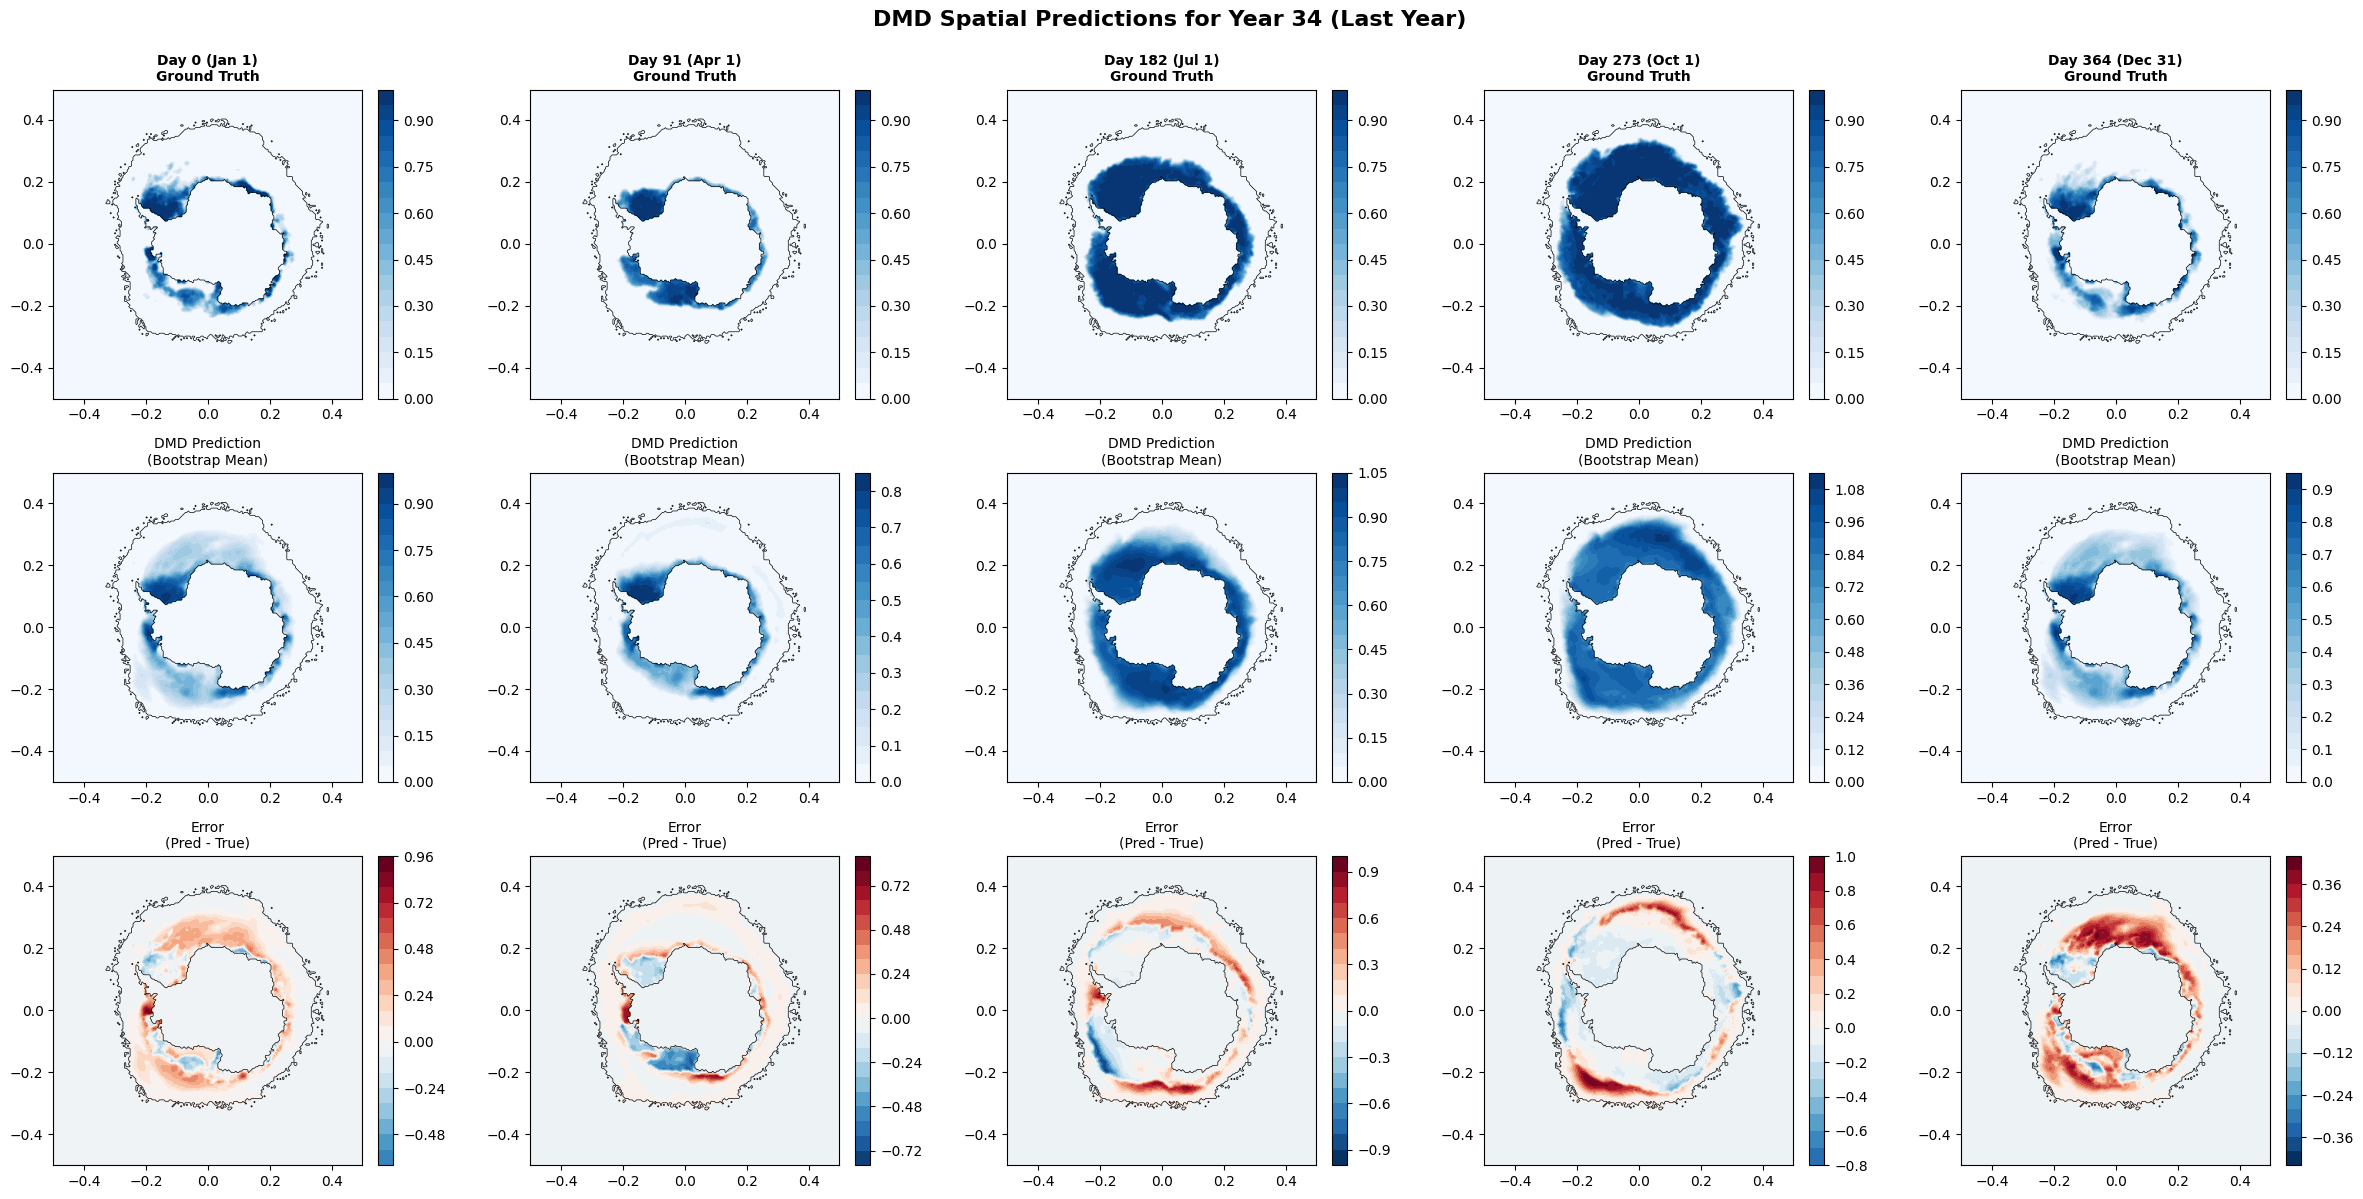


--- Year 34 Spatial Statistics ---
Day 0 (Jan 1)       : RMSE = 7.748680e-02, MAE = 2.262358e-02
Day 91 (Apr 1)      : RMSE = 7.395533e-02, MAE = 1.664345e-02
Day 182 (Jul 1)     : RMSE = 9.701236e-02, MAE = 2.598049e-02
Day 273 (Oct 1)     : RMSE = 1.087096e-01, MAE = 3.216621e-02
Day 364 (Dec 31)    : RMSE = 6.364678e-02, MAE = 1.918735e-02


In [13]:
# Visualize spatial predictions for selected days
selected_days = [0, 91, 182, 273, 364]  # Start, Q1, Mid, Q3, End of year
day_labels = ['Day 0 (Jan 1)', 'Day 91 (Apr 1)', 'Day 182 (Jul 1)', 
              'Day 273 (Oct 1)', 'Day 364 (Dec 31)']

fig, axes = plt.subplots(3, len(selected_days), figsize=(24, 12))

for idx, (day, label) in enumerate(zip(selected_days, day_labels)):
    # Ground truth
    ax1 = axes[0, idx]
    im1 = ax1.contourf(x, y, y_true_last[day, :, :], levels=20, cmap='Blues')
    ax1.contour(x, y, mask_ice, levels=[0.5], colors='black', linewidths=0.5)
    ax1.set_title(f'{label}\nGround Truth', fontsize=10, fontweight='bold')
    ax1.set_aspect('equal')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    
    # DMD Prediction (mean)
    ax2 = axes[1, idx]
    im2 = ax2.contourf(x, y, y_pred_last_mean[day, :, :], levels=20, cmap='Blues')
    ax2.contour(x, y, mask_ice, levels=[0.5], colors='black', linewidths=0.5)
    ax2.set_title(f'DMD Prediction\n(Bootstrap Mean)', fontsize=10)
    ax2.set_aspect('equal')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)
    
    # Prediction Error
    ax3 = axes[2, idx]
    error = y_pred_last_mean[day, :, :] - y_true_last[day, :, :]
    vmax = np.max(np.abs(error))
    im3 = ax3.contourf(x, y, error, levels=20, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax3.contour(x, y, mask_ice, levels=[0.5], colors='black', linewidths=0.5)
    ax3.set_title(f'Error\n(Pred - True)', fontsize=10)
    ax3.set_aspect('equal')
    plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)

fig.suptitle(f'DMD Spatial Predictions for Year {year} (Last Year)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# Print statistics
print(f"\n--- Year {year} Spatial Statistics ---")
for day, label in zip(selected_days, day_labels):
    rmse_day = np.sqrt(np.mean((y_pred_last_mean[day] - y_true_last[day])**2))
    mae_day = np.mean(np.abs(y_pred_last_mean[day] - y_true_last[day]))
    print(f"{label:20s}: RMSE = {rmse_day:.6e}, MAE = {mae_day:.6e}")

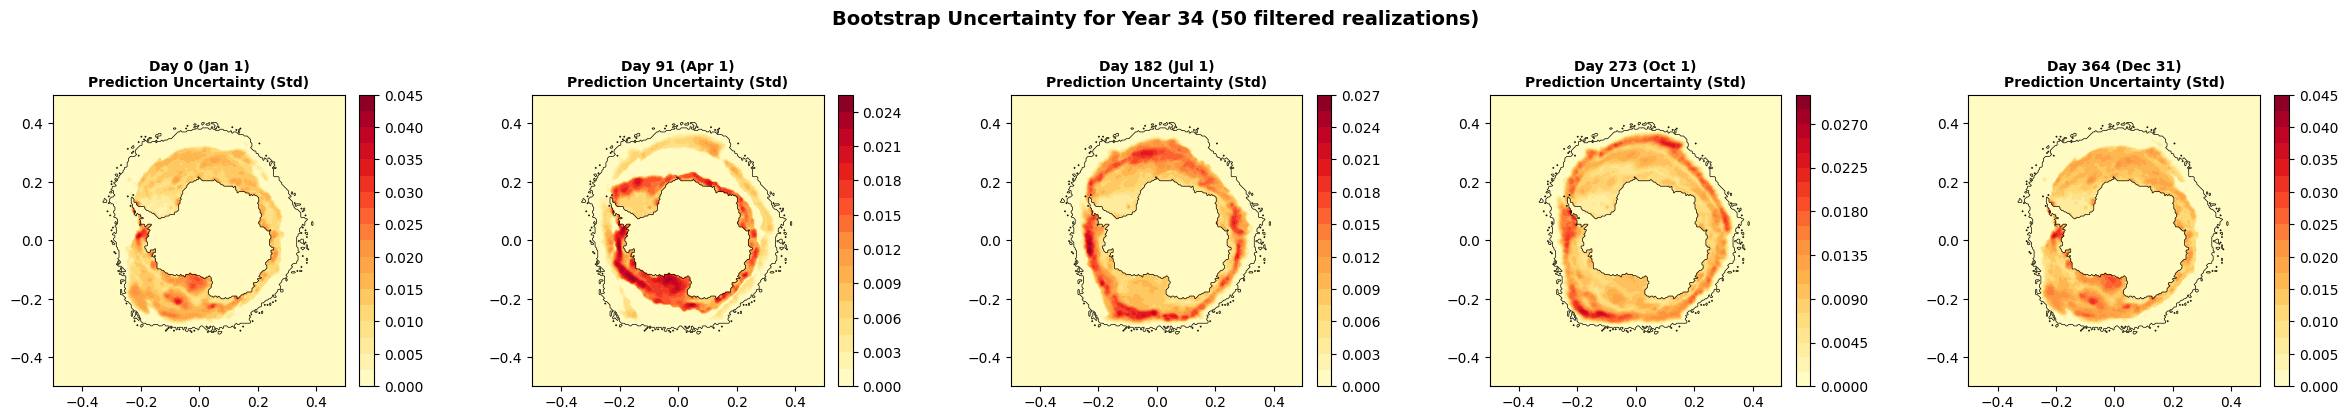


--- Year 34 Uncertainty Statistics ---
Day 0 (Jan 1)       : Mean Std = 1.794397e-03, Max Std = 4.276066e-02
Day 91 (Apr 1)      : Mean Std = 1.162749e-03, Max Std = 2.447362e-02
Day 182 (Jul 1)     : Mean Std = 1.608185e-03, Max Std = 2.650226e-02
Day 273 (Oct 1)     : Mean Std = 1.799729e-03, Max Std = 2.903009e-02
Day 364 (Dec 31)    : Mean Std = 2.013175e-03, Max Std = 4.269242e-02


In [14]:
# Visualize uncertainty (bootstrap std) for the same days
fig, axes = plt.subplots(1, len(selected_days), figsize=(24, 4))

for idx, (day, label) in enumerate(zip(selected_days, day_labels)):
    ax = axes[idx]
    
    # Bootstrap standard deviation
    im = ax.contourf(x, y, y_pred_last_std[day, :, :], levels=20, cmap='YlOrRd')
    ax.contour(x, y, mask_ice, levels=[0.5], colors='black', linewidths=0.5)
    ax.set_title(f'{label}\nPrediction Uncertainty (Std)', fontsize=10, fontweight='bold')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle(f'Bootstrap Uncertainty for Year {year} ({n_good_last} filtered realizations)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print uncertainty statistics
print(f"\n--- Year {year} Uncertainty Statistics ---")
for day, label in zip(selected_days, day_labels):
    mean_std = np.mean(y_pred_last_std[day])
    max_std = np.max(y_pred_last_std[day])
    print(f"{label:20s}: Mean Std = {mean_std:.6e}, Max Std = {max_std:.6e}")

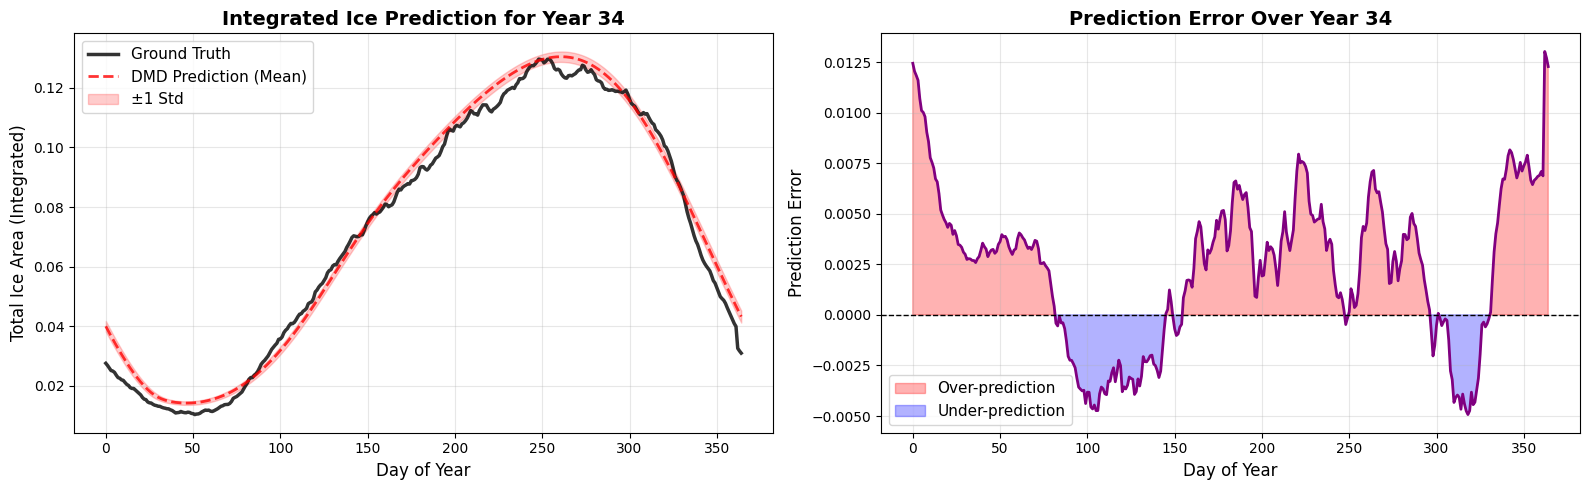


--- Year 34 Annual Statistics ---
MSE (integrated ice):  2.011901e-05
RMSE (integrated ice): 4.485422e-03
MAE (integrated ice):  3.797348e-03
Correlation:           0.9957


In [15]:
# Time evolution comparison for last year
# Compare integrated ice over the full year

I_pred_last = np.trapz(np.trapz(y_pred_last_mean, y, axis=2), x, axis=1)
I_true_last_year = np.trapz(np.trapz(y_true_last, y, axis=2), x, axis=1)

plt.figure(figsize=(16, 5))

# Full year comparison
plt.subplot(1, 2, 1)
plt.plot(t_test_year, I_true_last_year, label='Ground Truth', 
         color='black', linewidth=2.5, alpha=0.8)
plt.plot(t_test_year, I_pred_last, label='DMD Prediction (Mean)', 
         color='red', linestyle='--', linewidth=2, alpha=0.8)

# Add uncertainty band if we have std
I_pred_last_std_1d = np.trapz(np.trapz(y_pred_last_std, y, axis=2), x, axis=1)
plt.fill_between(t_test_year, 
                 I_pred_last - I_pred_last_std_1d,
                 I_pred_last + I_pred_last_std_1d,
                 color='red', alpha=0.2, label='±1 Std')

plt.xlabel('Day of Year', fontsize=12)
plt.ylabel('Total Ice Area (Integrated)', fontsize=12)
plt.title(f'Integrated Ice Prediction for Year {year}', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)

# Error over time
plt.subplot(1, 2, 2)
error_integrated = I_pred_last - I_true_last_year
plt.plot(t_test_year, error_integrated, color='purple', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.fill_between(t_test_year, error_integrated, 0, 
                 where=(error_integrated >= 0), color='red', alpha=0.3, label='Over-prediction')
plt.fill_between(t_test_year, error_integrated, 0, 
                 where=(error_integrated < 0), color='blue', alpha=0.3, label='Under-prediction')

plt.xlabel('Day of Year', fontsize=12)
plt.ylabel('Prediction Error', fontsize=12)
plt.title(f'Prediction Error Over Year {year}', fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print annual statistics
mse_annual = np.mean(error_integrated**2)
mae_annual = np.mean(np.abs(error_integrated))
rmse_annual = np.sqrt(mse_annual)

print(f"\n--- Year {year} Annual Statistics ---")
print(f"MSE (integrated ice):  {mse_annual:.6e}")
print(f"RMSE (integrated ice): {rmse_annual:.6e}")
print(f"MAE (integrated ice):  {mae_annual:.6e}")
print(f"Correlation:           {np.corrcoef(I_pred_last, I_true_last_year)[0, 1]:.4f}")

In [ ]:
# Visual comparison of predictions vs ground truth using contour_compare
contour_compare(y_pred_last_mean, y_true_last, x, y, mask_ice)

interactive(children=(IntSlider(value=0, description='f_i(x,y)', max=364), IntSlider(value=108, description='f…

## DMD Latent Coefficients Time Series

Visualize the evolution of all 5 DMD latent coefficients over time

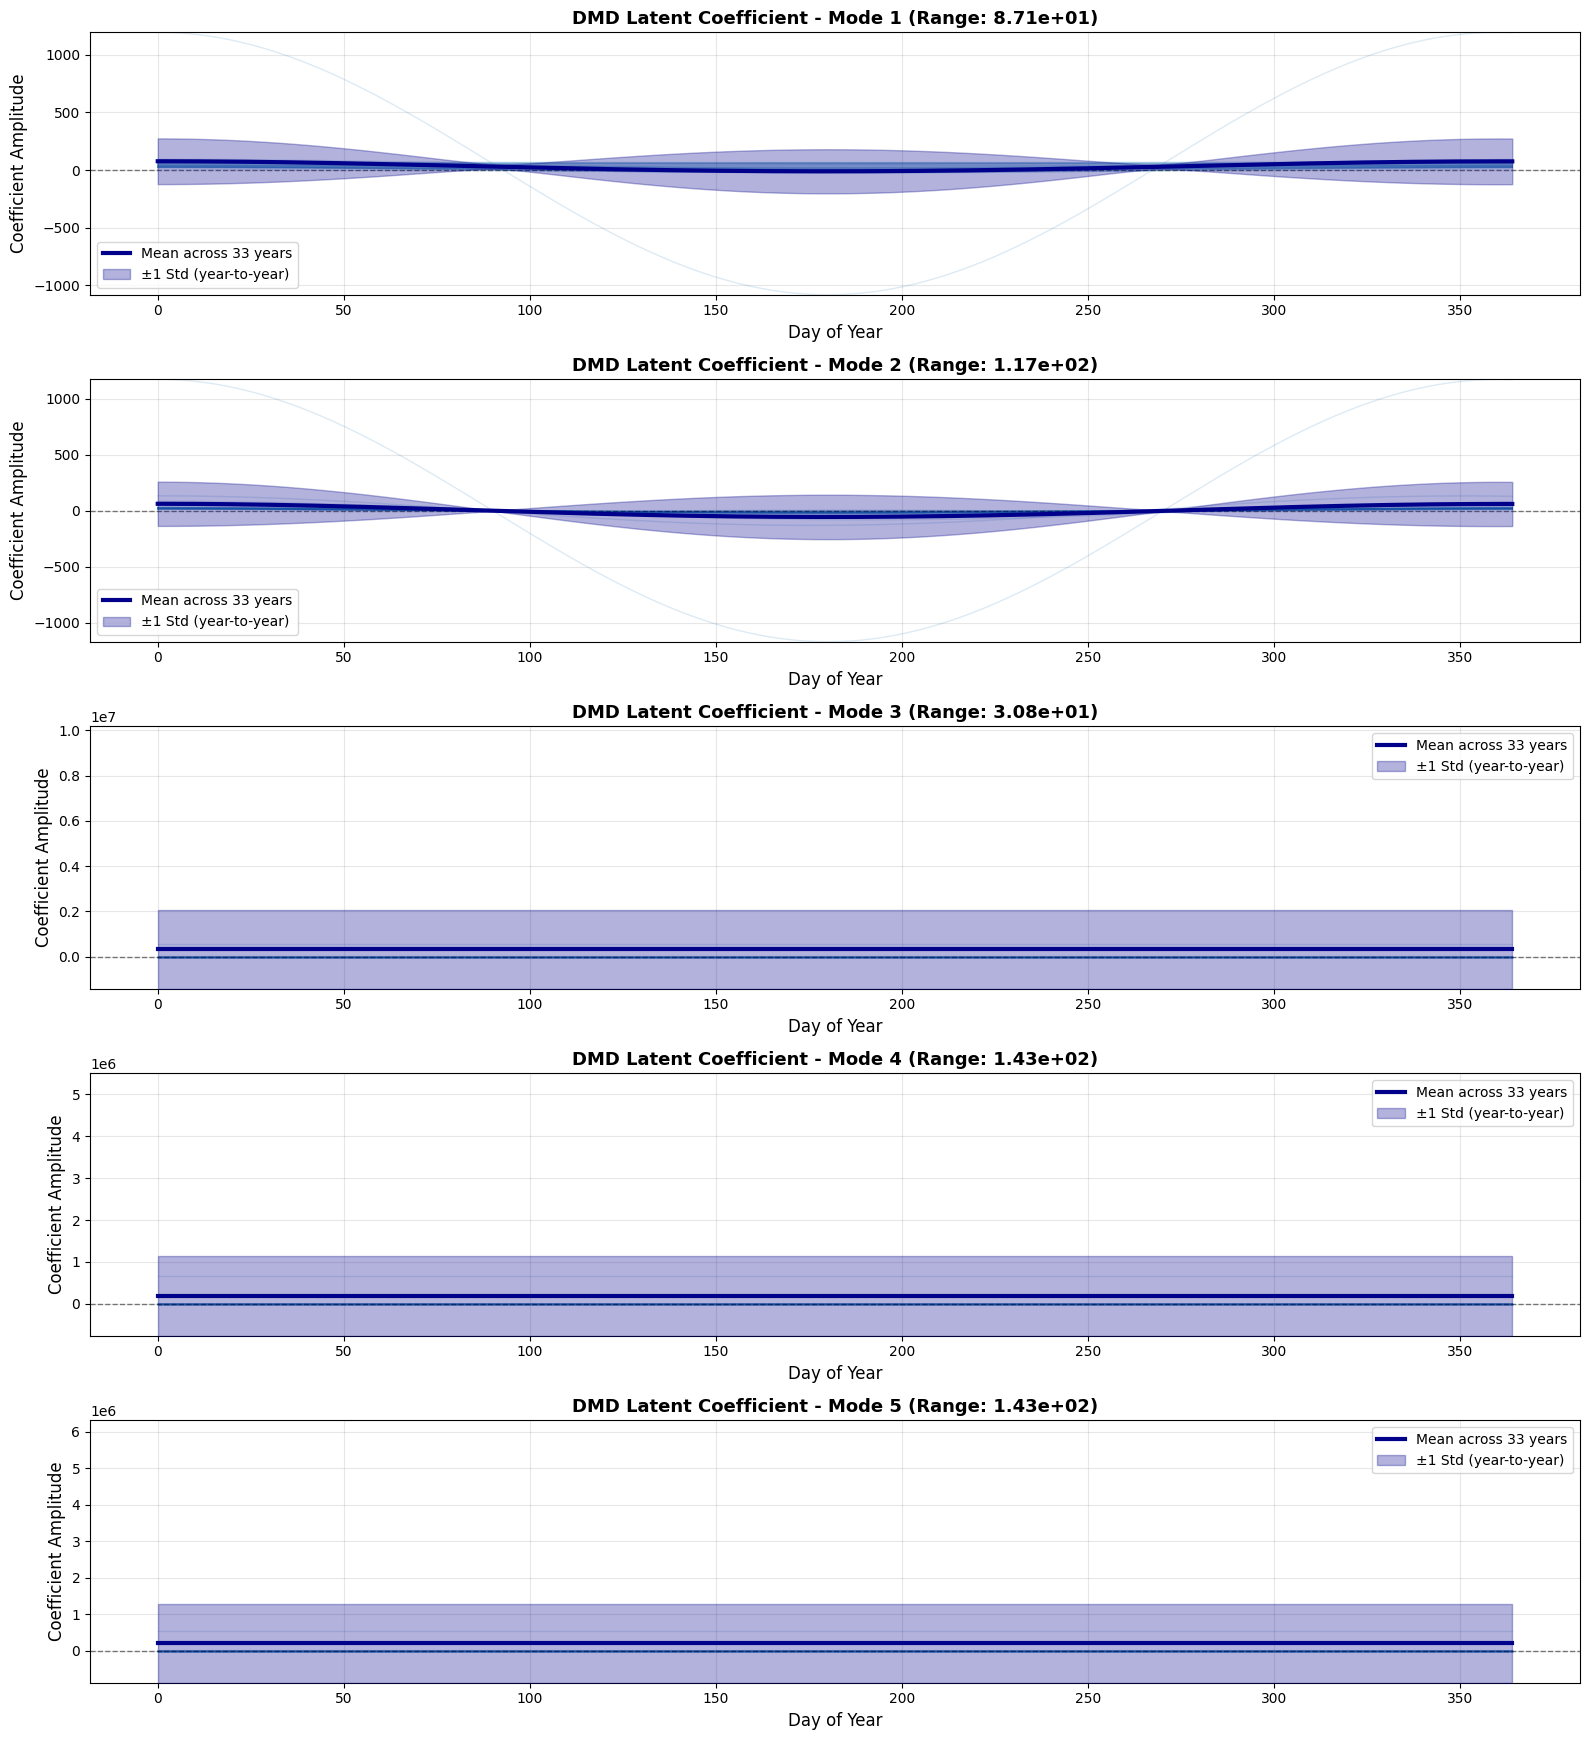


--- DMD Latent Coefficient Statistics (All 33 Years) ---

Mode 1:
  Mean:  3.204570e+01
  Std:   1.430561e+02
  Range: [-1.081060e+03, 1.195286e+03]

Mode 2:
  Mean:  7.081804e-01
  Std:   1.470248e+02
  Range: [-1.170912e+03, 1.172493e+03]

Mode 3:
  Mean:  3.252790e+05
  Std:   1.744548e+06
  Range: [-1.319611e+02, 1.017994e+07]

Mode 4:
  Mean:  1.872470e+05
  Std:   9.461116e+05
  Range: [-1.156887e+03, 5.499498e+06]

Mode 5:
  Mean:  2.080339e+05
  Std:   1.084137e+06
  Range: [-1.156887e+03, 6.318570e+06]


In [17]:
# Plot time series of all DMD latent coefficients across all 30 years
# z_pred_mean_all has shape (30, 365, rank)

# Better visualization: Show all years aligned on same 365-day axis to see consistency
# Each mode gets its own y-axis scale to reveal temporal patterns
fig, axes = plt.subplots(rank, 1, figsize=(16, 3.5 * rank))

for mode_idx in range(rank):
    ax = axes[mode_idx]
    
    # Plot each year's trajectory (all aligned to same day-of-year axis)
    for year_idx in range(len(years)):
        z_year = np.real(z_pred_mean_all[year_idx, :, mode_idx])  # Shape: (365,)
        
        # Plot all years with transparency to see overall pattern
        ax.plot(t_test_year, z_year, linewidth=1, alpha=0.15, color='C0')
    
    # Compute and plot mean trajectory across all years
    z_mean_across_years = np.real(z_pred_mean_all[:, :, mode_idx]).mean(axis=0)  # (365,)
    z_std_across_years = np.real(z_pred_mean_all[:, :, mode_idx]).std(axis=0)    # (365,)
    
    ax.plot(t_test_year, z_mean_across_years, linewidth=3, color='darkblue', 
            label=f'Mean across {len(years)} years', zorder=10)
    ax.fill_between(t_test_year, 
                    z_mean_across_years - z_std_across_years,
                    z_mean_across_years + z_std_across_years,
                    alpha=0.3, color='darkblue', label='±1 Std (year-to-year)', zorder=5)
    
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)
    ax.set_xlabel('Day of Year', fontsize=12)
    ax.set_ylabel('Coefficient Amplitude', fontsize=12)
    
    # Add scale info to title
    y_range = z_mean_across_years.max() - z_mean_across_years.min()
    ax.set_title(f'DMD Latent Coefficient - Mode {mode_idx+1} (Range: {y_range:.2e})', 
                fontsize=13, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Auto-scale y-axis for each mode independently
    ax.autoscale(enable=True, axis='y', tight=True)

plt.tight_layout()
plt.show()

# Print statistics for each mode across all years
print(f"\n--- DMD Latent Coefficient Statistics (All {len(years)} Years) ---")
for mode_idx in range(rank):
    # Flatten across all years and days
    z_mode_all = np.real(z_pred_mean_all[:, :, mode_idx]).flatten()
    
    print(f"\nMode {mode_idx+1}:")
    print(f"  Mean:  {z_mode_all.mean():.6e}")
    print(f"  Std:   {z_mode_all.std():.6e}")
    print(f"  Range: [{z_mode_all.min():.6e}, {z_mode_all.max():.6e}]")

## Analyse DMD Modes

Analysis of eigenvalue distributions across bootstrap ensemble

In [18]:
# Shape of eigenvalue array for last year
L_s_last.shape

(50, 5)

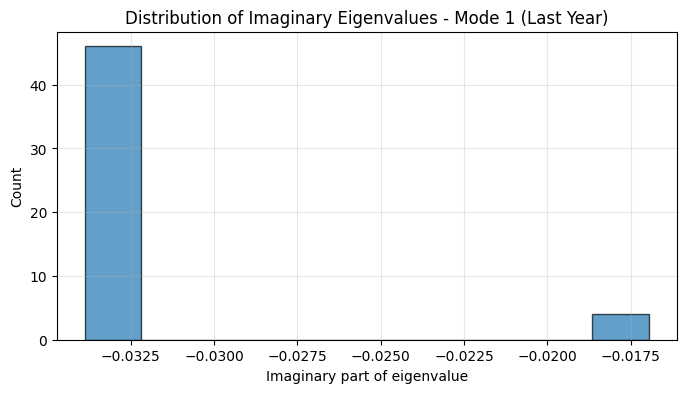

In [26]:
# Histogram of imaginary eigenvalues for mode 1 (index 0)
plt.figure(figsize=(8, 4))
plt.hist(L_s_last.imag[:, 4], bins=10, edgecolor='black', alpha=0.7)
plt.xlabel('Imaginary part of eigenvalue')
plt.ylabel('Count')
plt.title('Distribution of Imaginary Eigenvalues - Mode 1 (Last Year)')
plt.grid(True, alpha=0.3)
plt.show()

In [27]:
# Median eigenvalues across bootstrap ensemble
median_eigs = np.median(L_s_last, axis=0)
print("Median eigenvalues (complex):")
for i, eig in enumerate(median_eigs):
    print(f"  Mode {i+1}: {eig:.6f}")
median_eigs

Median eigenvalues (complex):
  Mode 1: -0.000186+0.000000j
  Mode 2: 0.000000+0.016970j
  Mode 3: 0.000000-0.016974j
  Mode 4: 0.000000+0.033781j
  Mode 5: 0.000000-0.033781j


array([-0.00018634+0.j        ,  0.        +0.01697041j,
        0.        -0.01697374j,  0.        +0.03378105j,
        0.        -0.03378105j])

In [28]:
# Median of imaginary parts only
median_imag = np.median(L_s_last.imag, axis=0)
print("Median imaginary parts:")
for i, imag in enumerate(median_imag):
    if imag != 0:
        period_years = 2*np.pi / imag / 365
        print(f"  Mode {i+1}: {imag:.8f} (period: {period_years:.3f} years)")
    else:
        print(f"  Mode {i+1}: {imag:.8f} (non-oscillatory)")
median_imag

Median imaginary parts:
  Mode 1: 0.00000000 (non-oscillatory)
  Mode 2: 0.01697041 (period: 1.014 years)
  Mode 3: -0.01697041 (period: -1.014 years)
  Mode 4: 0.03378105 (period: 0.510 years)
  Mode 5: -0.03378105 (period: -0.510 years)


array([ 0.        ,  0.01697041, -0.01697041,  0.03378105, -0.03378105])

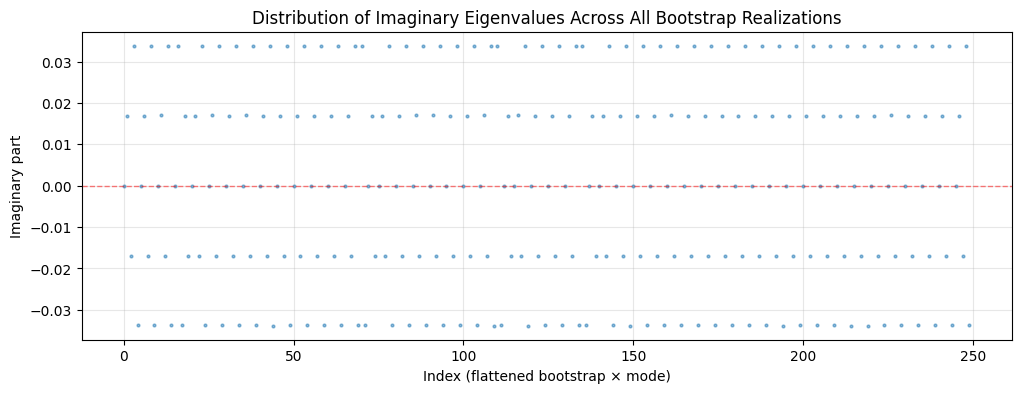

In [29]:
# Scatter plot of all imaginary eigenvalues across bootstrap
plt.figure(figsize=(12, 4))
plt.plot(L_s_last.imag.flatten(), '.', alpha=0.5, markersize=4)
plt.xlabel('Index (flattened bootstrap × mode)')
plt.ylabel('Imaginary part')
plt.title('Distribution of Imaginary Eigenvalues Across All Bootstrap Realizations')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.show()

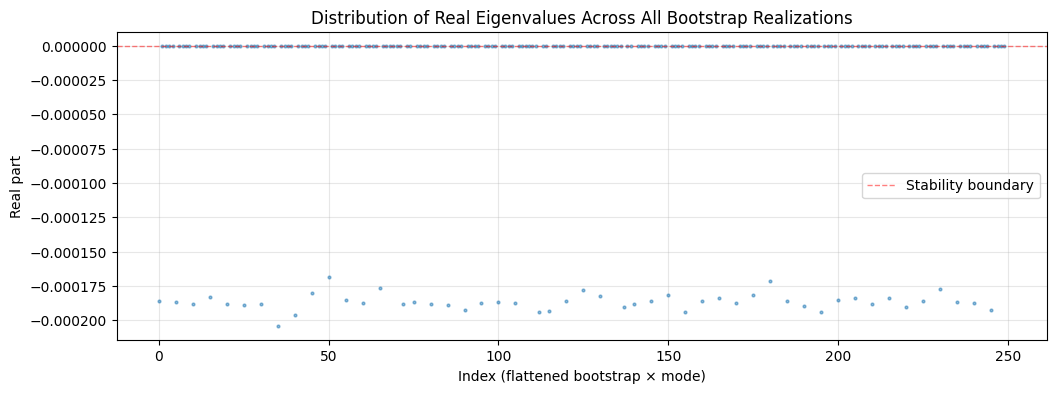

In [30]:
# Scatter plot of all real eigenvalues across bootstrap
plt.figure(figsize=(12, 4))
plt.plot(L_s_last.real.flatten(), '.', alpha=0.5, markersize=4)
plt.xlabel('Index (flattened bootstrap × mode)')
plt.ylabel('Real part')
plt.title('Distribution of Real Eigenvalues Across All Bootstrap Realizations')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Stability boundary')
plt.legend()
plt.show()

## Analyze DMD Mode Characteristics

Check eigenvalues and spatial pattern magnitudes to understand why modes 3-5 have much larger coefficients

In [31]:
# Analyze eigenvalues and mode characteristics for the last year
# to understand why modes 3-5 have much larger coefficients

last_year_idx = -1
year = years[last_year_idx]

# Get DMD parameters for last year
L_s_last = L_tot[last_year_idx]      # (N_good_last, rank)
Psi_s_last = Psi_tot[last_year_idx]  # (N_good_last, rank, ny, nx)
bn_s_last = bn_tot[last_year_idx]    # (N_good_last, rank)

# Compute average eigenvalues and initial coefficients across bootstrap ensemble
L_avg = L_s_last.mean(axis=0)        # (rank,) - average eigenvalues
bn_avg = bn_s_last.mean(axis=0)      # (rank,) - average initial coefficients
Psi_avg = Psi_s_last.mean(axis=0)    # (rank, ny, nx) - average spatial modes

print(f"=== DMD Mode Analysis for Year {year} ===\n")
print("Mode characteristics (averaged across bootstrap ensemble):\n")

for mode_idx in range(rank):
    eigenval = L_avg[mode_idx]
    init_coeff = bn_avg[mode_idx]
    spatial_mode = Psi_avg[mode_idx]
    
    # Eigenvalue properties
    magnitude = np.abs(eigenval)
    phase = np.angle(eigenval)
    frequency = phase / (2 * np.pi)  # Cycles per time unit
    
    # Spatial mode properties
    spatial_norm = np.linalg.norm(spatial_mode)
    spatial_max = np.abs(spatial_mode).max()
    spatial_mean = np.abs(spatial_mode).mean()
    
    # Time evolution properties (at t=365)
    z_t365 = init_coeff * (eigenval ** 365)
    
    print(f"Mode {mode_idx + 1}:")
    print(f"  Eigenvalue λ:      {eigenval:.6e}  (|λ| = {magnitude:.6f})")
    print(f"  Frequency:         {frequency:.6e} cycles/day")
    print(f"  Initial coeff b_n: {init_coeff:.6e}  (magnitude: {np.abs(init_coeff):.6e})")
    print(f"  Spatial ||Ψ||:     {spatial_norm:.6e}")
    print(f"  Spatial max(|Ψ|):  {spatial_max:.6e}")
    print(f"  Spatial mean(|Ψ|): {spatial_mean:.6e}")
    print(f"  Coefficient @ t=365: {z_t365:.6e}")
    print(f"  Contribution scale (|b_n| × |Ψ|): {np.abs(init_coeff) * spatial_norm:.6e}")
    print()

=== DMD Mode Analysis for Year 34 ===

Mode characteristics (averaged across bootstrap ensemble):

Mode 1:
  Eigenvalue λ:      -1.750306e-04+2.026051e-03j  (|λ| = 0.002034)
  Frequency:         2.637153e-01 cycles/day
  Initial coeff b_n: 5.833248e+01  (magnitude: 5.833248e+01)
  Spatial ||Ψ||:     6.663576e-01
  Spatial max(|Ψ|):  1.418285e-02
  Spatial mean(|Ψ|): 1.108625e-03
  Coefficient @ t=365: -0.000000e+00+0.000000e+00j
  Contribution scale (|b_n| × |Ψ|): 3.887030e+01

Mode 2:
  Eigenvalue λ:      0.000000e+00+1.426417e-02j  (|λ| = 0.014264)
  Frequency:         2.500000e-01 cycles/day
  Initial coeff b_n: 2.516895e+01  (magnitude: 2.516895e+01)
  Spatial ||Ψ||:     6.447073e-01
  Spatial max(|Ψ|):  1.081333e-02
  Spatial mean(|Ψ|): 1.137292e-03
  Coefficient @ t=365: -0.000000e+00+0.000000e+00j
  Contribution scale (|b_n| × |Ψ|): 1.622661e+01

Mode 3:
  Eigenvalue λ:      -1.144483e-05-1.629022e-02j  (|λ| = 0.016290)
  Frequency:         -2.501118e-01 cycles/day
  Initial coe

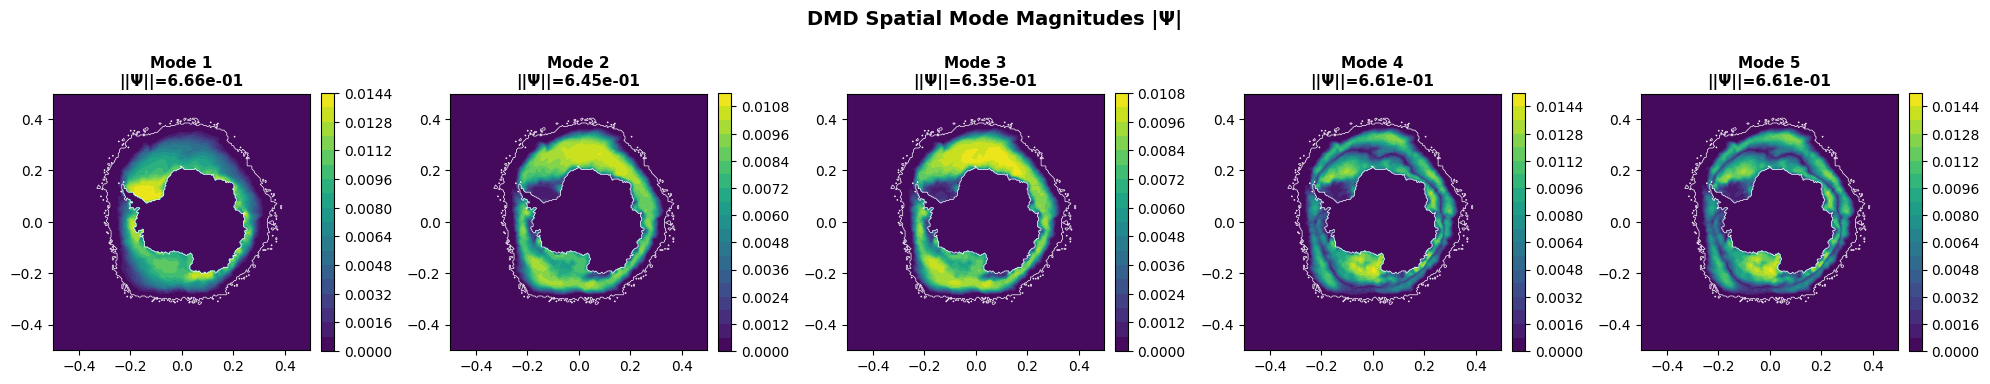


💡 Key insight:
If modes 3-5 have SMALLER spatial patterns (smaller ||Ψ||),
they need LARGER coefficients to contribute equally to the reconstruction.


In [32]:
# Visualize the spatial patterns to see if modes 3-5 have smaller magnitudes

fig, axes = plt.subplots(1, rank, figsize=(20, 4))

for mode_idx in range(rank):
    ax = axes[mode_idx]
    spatial_mode = np.abs(Psi_avg[mode_idx])  # Magnitude of spatial pattern
    
    im = ax.contourf(x, y, spatial_mode, levels=20, cmap='viridis')
    ax.contour(x, y, mask_ice, levels=[0.5], colors='white', linewidths=0.5)
    ax.set_title(f'Mode {mode_idx+1}\n||Ψ||={np.linalg.norm(spatial_mode):.2e}', 
                 fontsize=11, fontweight='bold')
    ax.set_aspect('equal')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle('DMD Spatial Mode Magnitudes |Ψ|', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Key insight:")
print("If modes 3-5 have SMALLER spatial patterns (smaller ||Ψ||),")
print("they need LARGER coefficients to contribute equally to the reconstruction.")

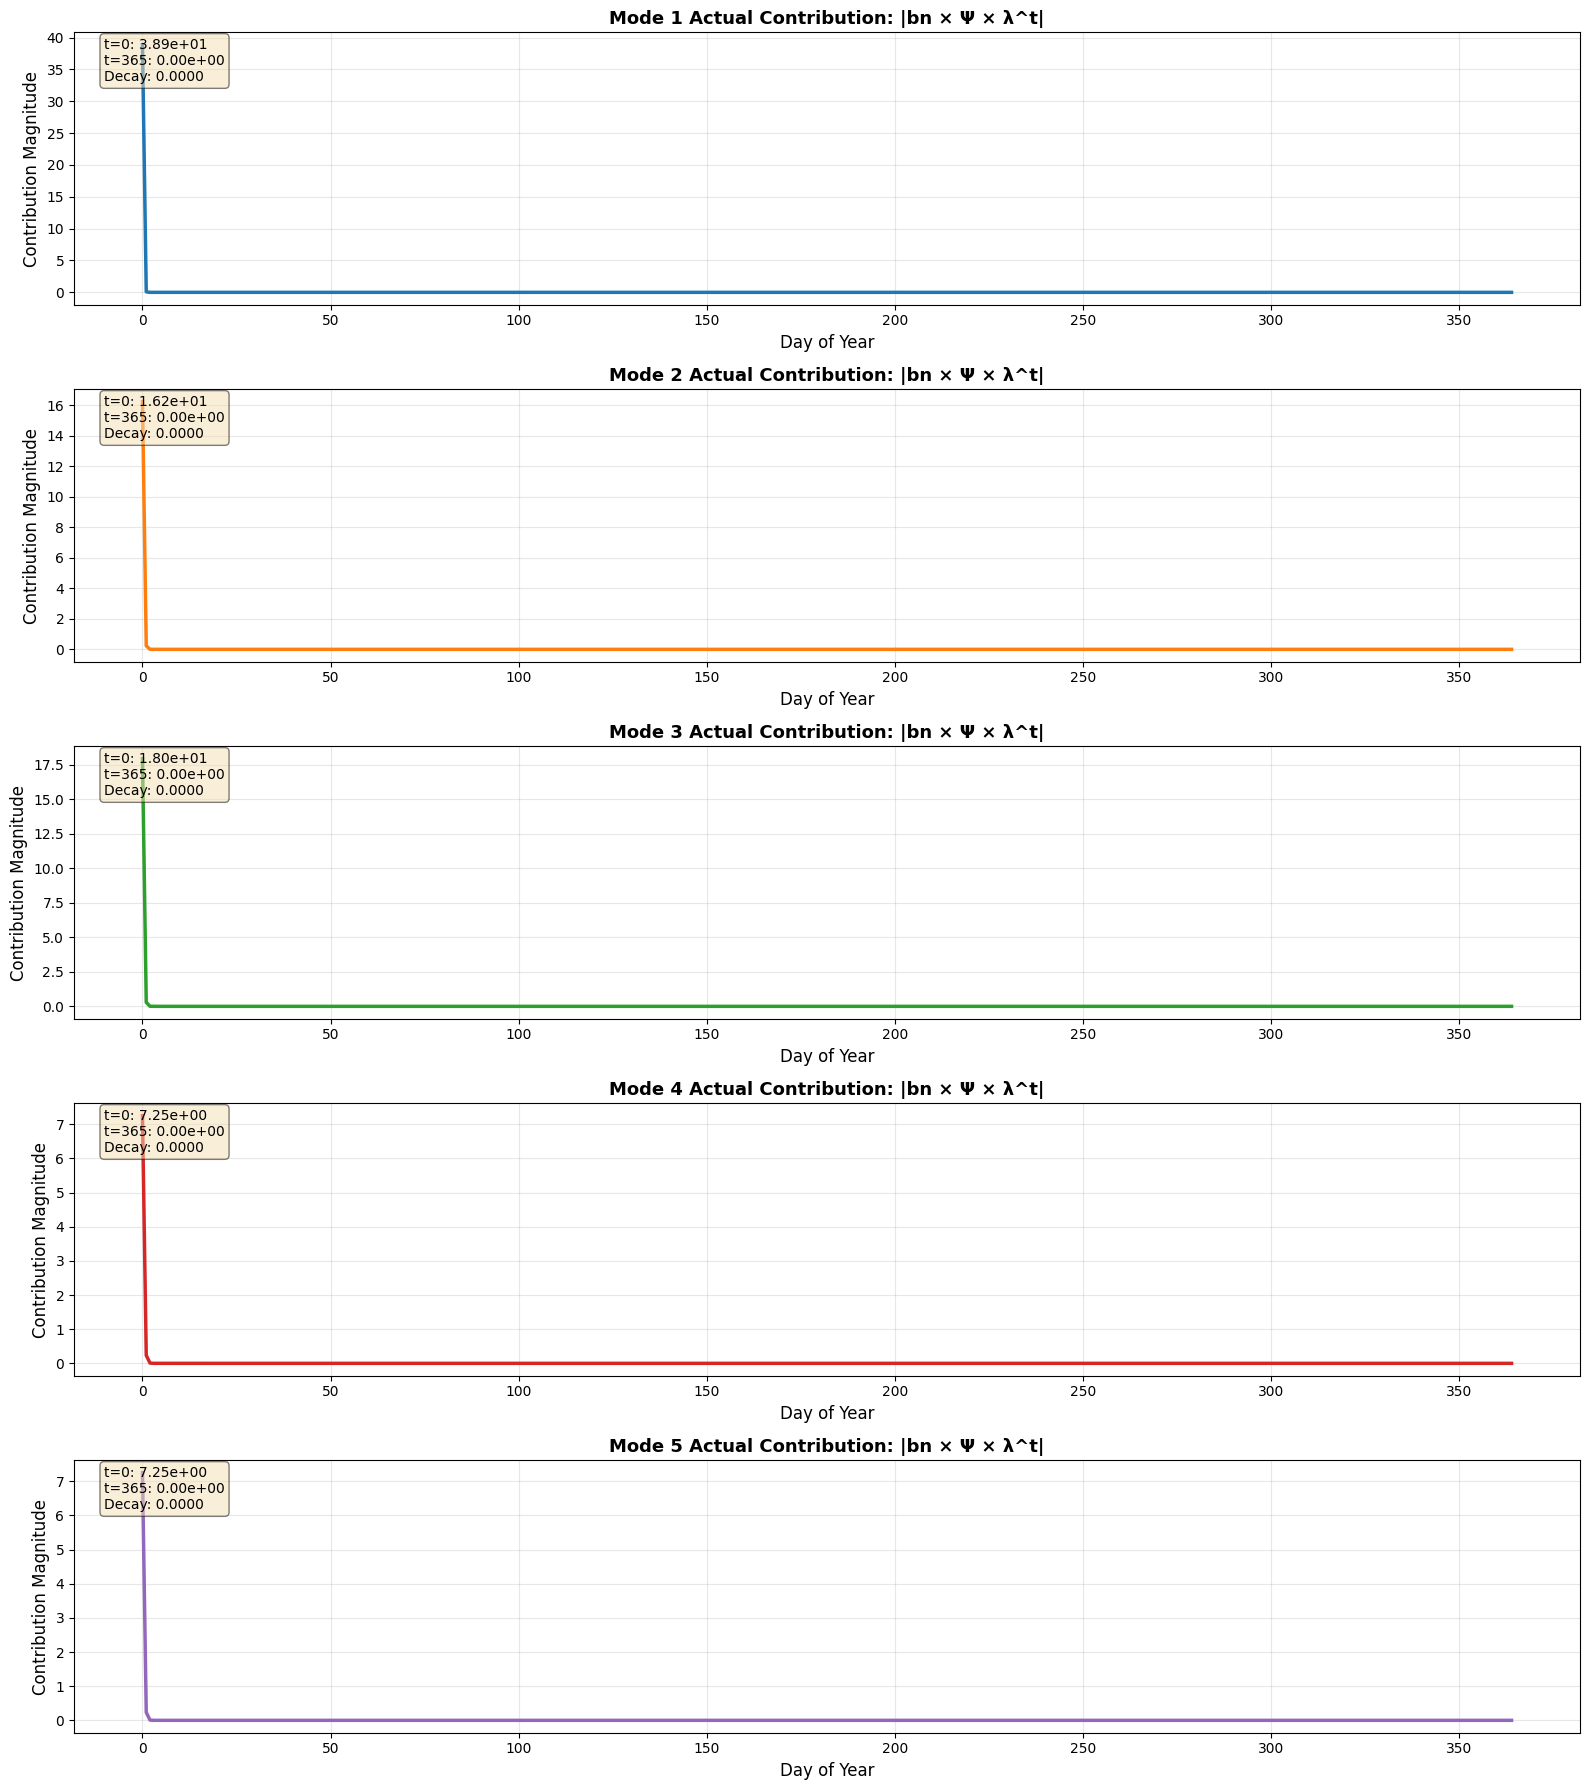


=== Mode Contribution Summary ===
This shows the ACTUAL contribution of each mode to the reconstruction
Formula: |bn × ||Ψ|| × λ^t|

Mode 1:
  Initial contribution (t=0):   3.887030e+01
  Final contribution (t=365):   0.000000e+00
  Eigenvalue decay factor:      0.000000
  Relative importance @ t=365:  nan%

Mode 2:
  Initial contribution (t=0):   1.622661e+01
  Final contribution (t=365):   0.000000e+00
  Eigenvalue decay factor:      0.000000
  Relative importance @ t=365:  nan%

Mode 3:
  Initial contribution (t=0):   1.795415e+01
  Final contribution (t=365):   0.000000e+00
  Eigenvalue decay factor:      0.000000
  Relative importance @ t=365:  nan%

Mode 4:
  Initial contribution (t=0):   7.249650e+00
  Final contribution (t=365):   0.000000e+00
  Eigenvalue decay factor:      0.000000
  Relative importance @ t=365:  nan%

Mode 5:
  Initial contribution (t=0):   7.249650e+00
  Final contribution (t=365):   0.000000e+00
  Eigenvalue decay factor:      0.000000
  Relative importan

/var/folders/s8/_x7yhly96g707tvgp1hkr_bh0000gn/T/ipykernel_9195/2100300361.py:53: RuntimeWarning: invalid value encountered in scalar divide
  print(f"  Relative importance @ t=365:  {contrib_365/np.sum([np.abs(bn_avg[i] * np.linalg.norm(Psi_avg[i]) * (L_avg[i] ** 365)) for i in range(rank)]):.2%}")


In [34]:
# Compute actual mode contributions over time: |bn × Ψ × λ^t|
# This shows what each mode actually contributes to the reconstruction

fig, axes = plt.subplots(5, 1, figsize=(16, 18))

for mode_idx in range(rank):
    ax = axes[mode_idx]
    
    eigenval = L_avg[mode_idx]
    init_coeff = bn_avg[mode_idx]
    spatial_norm = np.linalg.norm(Psi_avg[mode_idx])
    
    # Compute contribution over time
    t_range = np.arange(0, 365)
    contribution = np.abs(init_coeff * spatial_norm * (eigenval ** t_range))
    
    ax.plot(t_range, contribution, linewidth=2.5, color=f'C{mode_idx}')
    ax.set_xlabel('Day of Year', fontsize=12)
    ax.set_ylabel('Contribution Magnitude', fontsize=12)
    ax.set_title(f'Mode {mode_idx+1} Actual Contribution: |bn × Ψ × λ^t|', 
                fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # Add text with initial and final values
    contrib_0 = contribution[0]
    contrib_365 = contribution[-1]
    ax.text(0.02, 0.98, 
            f't=0: {contrib_0:.2e}\nt=365: {contrib_365:.2e}\nDecay: {contrib_365/contrib_0:.4f}',
            transform=ax.transAxes, fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Print summary
print("\n=== Mode Contribution Summary ===")
print("This shows the ACTUAL contribution of each mode to the reconstruction")
print("Formula: |bn × ||Ψ|| × λ^t|\n")

for mode_idx in range(rank):
    eigenval = L_avg[mode_idx]
    init_coeff = bn_avg[mode_idx]
    spatial_norm = np.linalg.norm(Psi_avg[mode_idx])
    
    contrib_0 = np.abs(init_coeff * spatial_norm)
    contrib_365 = np.abs(init_coeff * spatial_norm * (eigenval ** 365))
    decay_factor = np.abs(eigenval) ** 365
    
    print(f"Mode {mode_idx+1}:")
    print(f"  Initial contribution (t=0):   {contrib_0:.6e}")
    print(f"  Final contribution (t=365):   {contrib_365:.6e}")
    print(f"  Eigenvalue decay factor:      {decay_factor:.6f}")
    print(f"  Relative importance @ t=365:  {contrib_365/np.sum([np.abs(bn_avg[i] * np.linalg.norm(Psi_avg[i]) * (L_avg[i] ** 365)) for i in range(rank)]):.2%}")
    print()